In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

In [3]:
#loading dataset
mnist=fetch_openml('mnist_784')
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
mnist.DESCR

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [5]:
X=mnist.data.to_numpy()
y=mnist.target.to_numpy()

X.shape

(70000, 784)

In [6]:
type(X)

numpy.ndarray

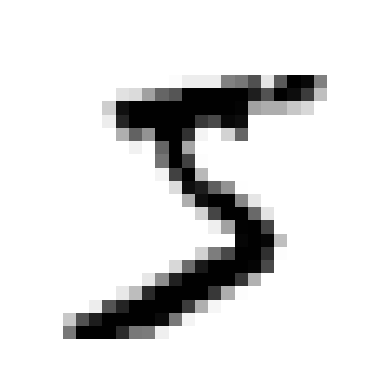

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit=X[0]
some_digit_image=some_digit.reshape(28,28)

plt.imshow(some_digit_image,cmap=mpl.cm.binary,interpolation="nearest")
plt.axis("off")
plt.show()

In [8]:
y[3]

'1'

In [9]:
type(y[0])

str

In [10]:
# we need numbers in order to train a model
y=y.astype(np.uint8)

In [11]:
type(y[0])

numpy.uint8

In [12]:
# seperating the training and test dataset

X_train,X_test,y_train,y_test=X[:60000],X[60000:],y[:60000],y[60000:]

In [13]:
# Building a smaller model which detect 5 or not 5
y_train_5=(y_train==5)
y_test_5=(y_test==5)

In [14]:
#Training a small binary classifier in order to make a classfier model which seperates 5 from others
from sklearn.linear_model import SGDClassifier
binary_model=SGDClassifier(random_state=42)
binary_model.fit(X_train,y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [15]:
binary_model.predict([some_digit])

array([ True])

In [16]:
# checking the model performance
from sklearn.metrics import *
from sklearn.model_selection import StratifiedGroupKFold,cross_val_score

score=cross_val_score(
    binary_model,
    X_test,
    y_test_5,
    cv=3,
    scoring="accuracy"
)

score

array([0.95110978, 0.95439544, 0.96879688])

In [17]:
# Wow as you can see that the accuracy is nearly 95% which is quite excellent for the model.
# Now we will like to make a model which return False whether the number is 5 or not.

In [18]:
from sklearn.base import BaseEstimator
import numpy as np

class Never5Classifier(BaseEstimator):
    def fit(self,X,y):
        return self

    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)

never_r=Never5Classifier()
never_5_score=cross_val_score(never_r,
                            X_test,
                            y_test_5,
                            cv=3,
                            scoring="accuracy")
never_5_score

array([0.90791842, 0.91029103, 0.91419142])

In [19]:
#so we can see that never5 has a accuracy of 90% meaning that the classification model 
# we used returned only 5% True and rest 5% false meaning only 50% real accucary

In [20]:
y_train_pred=binary_model.predict(X_train)

In [21]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[52316,  2263],
       [  601,  4820]])

In [22]:
#assuming we got the perfect score then 
y_train_perfect_pred=y_train_5
confusion_matrix(y_train_5,y_train_perfect_pred)

array([[54579,     0],
       [    0,  5421]])

In [23]:
#why it is preferred over accuracy 
never_5_pred=never_r.predict(X_train)
confusion_matrix(y_train_5,never_5_pred)

# As you see that the TP is zero meaning it never predicted a 5 meaning 0 accuracy 

array([[54579,     0],
       [ 5421,     0]])

In [24]:
# But still we need a better performance model rather than confusion matrix which should be more consise better to understand etx
from sklearn.metrics import precision_score
precision_score(y_train_5,y_train_pred)

0.6805026118876183

In [25]:
# But we cant use precision alone we use it with recall with it 
from sklearn.metrics import recall_score
recall_score(y_train_5,y_train_pred)

0.8891348459693783

In [26]:
# but its difficult to analyse them to together so we use F1 score a harmonic mean of both
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7709532949456174

In [27]:
# Using decision function to predict the target
data=X_train[:5]
data_decision=binary_model.decision_function(data)
threshold=100
print(data_decision > threshold)

[ True False False False False]


In [28]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [29]:
y_scores=cross_val_predict(
    estimator=binary_model,
    X=X_train,
    y=y_train_5,
    cv=3,
    method="decision_function"
)

In [30]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

In [31]:
# we are going to see how the precision and recall curve works
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_scores)


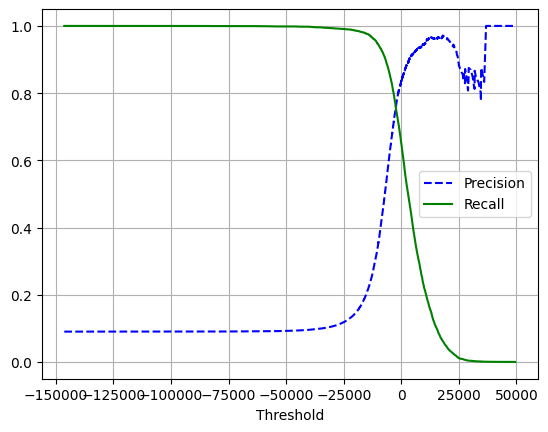

In [32]:
def plot_precision_recall_vs_threshold(precisions,recalls,thresholds):
    plt.plot(thresholds,precisions[:-1],"b--",label="Precision")
    plt.plot(thresholds,recalls[:-1],"g-",label="Recall")
    plt.legend(loc="best")
    plt.grid(True)
    plt.xlabel("Threshold")

plot_precision_recall_vs_threshold(precisions,recalls,thresholds)
plt.show()

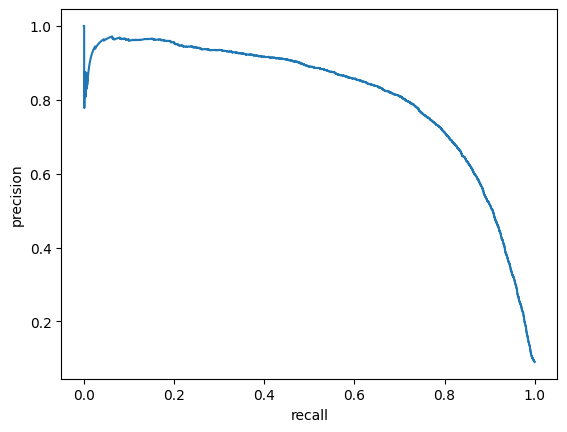

In [33]:
plt.plot(recalls[:-1],precisions[:-1])
plt.xlabel("recall")
plt.ylabel("precision")
plt.show()

In [34]:
threshold_90_precision=thresholds[np.argmax(precisions >=0.90)]

In [35]:
threshold_90_precision

np.float64(3370.0194991439557)

In [36]:
y_train_pred_90=(y_scores >= threshold_90_precision)


In [37]:
precision_score(y_train_5,y_train_pred_90)

0.9000345901072293

In [38]:
recall_score(y_train_5,y_train_pred_90)

0.4799852425751706

In [39]:
# how about we aim for maximum value we use f1_score
f1_scores=2*(precisions*recalls)/(precisions+recalls)
f1_scores

array([0.1657266 , 0.16572913, 0.16573167, ..., 0.0007376 , 0.00036887,
       0.        ], shape=(60001,))

In [40]:
best_index=np.argmax(f1_scores)
best_index
f1_scores[best_index]

np.float64(0.7590702947845804)

In [41]:
thresholds[best_index]

np.float64(-1991.7400221488995)

In [42]:
precisions[best_index]

np.float64(0.7780360255665311)

In [43]:
recalls[best_index]

np.float64(0.7410071942446043)

In [44]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds_roc=roc_curve(y_train_5,y_scores)

fpr

array([0.        , 0.        , 0.        , ..., 0.99937705, 0.99937705,
       1.        ], shape=(3908,))

C:\Users\Daksh\AppData\Local\Temp\ipykernel_30856\2582813397.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


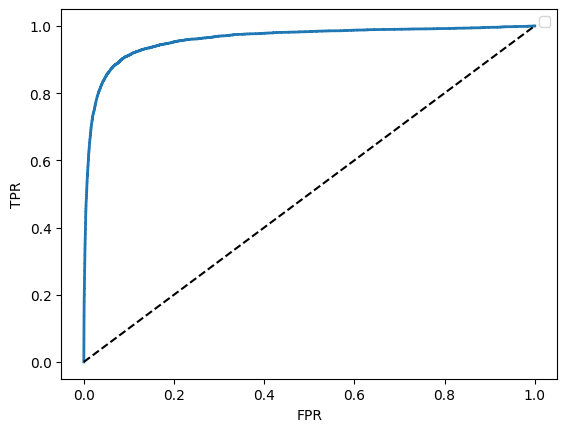

In [ ]:
plt.plot(fpr,tpr,linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()